<a href="https://colab.research.google.com/github/Serge3leo/temp-cola/blob/main/valq/260325/e_cos_x_dx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import scipy
from math import *
import matplotlib.pyplot as plt
# %matplotlib osx
%config InlineBackend.figure_format = "retina"

In [2]:
# Пытаемся понять, какая точность нужна
test_e = 0.1
test_x1 = -0.1
test_dx = 0.05
a = test_e*cos(pi/2 + test_x1)
b = test_e*cos(pi/2 + test_x1 + test_dx)
c = test_e*cos(pi/2 + test_x1 + 2.*test_dx)
abc_err = 0.00015  # Ошибка  чисел 0.00015 ????
# А нужно 0.000001 (1e-6)), как кажется
w = [1., 1., 1.]
max_e = 0.1
check_e = 0.5
max_nfev=None
if False:
    # Концепция изменилась. Я забыла умнижить на период. Правые части уравнений:0.0065,, 0.0043 и 0.0039
    a = 0.0065
    b = 0.0043
    c = 0.0039
    abc_err = 0.00015  # Ошибка  чисел 0.00015 ????
    w = [1., 1., 1.]
    max_e = 0.1
    check_e = 5
    max_nfev=None
if False:
    a = 0.0015
    b = 0.0010
    c = 0.0009

In [3]:
class common_method:
    def __init__(self, abc, base):
        self.abc = np.asarray(abc)
        self.w = np.array((1., 1., 1.))
        self.base = np.asarray(base)
    def x0(self):
        return self.base + np.array((np.average(self.abc), 0., 0.))
    def bounds(self):
        return np.array([self.base + np.array((0.,    -0.5, 0.)),
                         self.base + np.array((max_e, 0.,   0.5))])
    def print(self, x):
        print(x - self.base)

class cos_method(common_method):
    def __init__(self, abc):
        super().__init__(abc, np.array((0., np.pi/2., 0.)))
        self.jac = '3-point'  # {‘2-point’, ‘3-point’, ‘cs’, callable}, optional
        self.id = ['e', 'x', 'dx']
    def fun(self, arg):
        e = np.asarray(arg[0])
        x = np.asarray(arg[1])
        dx = np.asarray(arg[2])
        return [self.w[0]*(self.abc[0] - e*np.cos(x + 0.*dx)),
                self.w[1]*(self.abc[1] - e*np.cos(x + dx)),
                self.w[2]*(self.abc[2] - e*np.cos(x + 2.*dx))]

class cos_jac_method(cos_method):
    def __init__(self, abc):
        super().__init__(abc)
        self.jac = self._jac
    def _jac(self, arg):
        # print(f"{self.__class__.__name__, arg=}")
        e = np.asarray(arg[0])
        x = np.asarray(arg[1])
        dx = np.asarray(arg[2])
        return [
            self.w[0]*np.array((-np.cos(x),         e*np.sin(x),
                                0.)),
            self.w[1]*np.array((-np.cos(x + dx),    e*np.sin(x + dx),
                                e*np.sin(x + dx))),
            self.w[2]*np.array((-np.cos(x + 2.*dx), e*np.sin(x + 2.*dx),
                                2.*e*np.sin(x + 2.*dx))),
            ]

class sin_method(common_method):
    def __init__(self, abc):
        super().__init__(abc, np.zeros(3))
        self.jac =  '3-point'  # {‘2-point’, ‘3-point’, ‘cs’, callable}, optional
        self.id = ['e', 'x1', 'dx']
    def fun(self, arg):
        e = np.asarray(arg[0])
        x1 = np.asarray(arg[1])  # x == pi/2 + x1
        dx = np.asarray(arg[2])
        return [self.w[0]*(self.abc[0] + e*np.sin(x1 + 0.*dx)),
                self.w[1]*(self.abc[1] + e*np.sin(x1 + dx)),
                self.w[2]*(self.abc[2] + e*np.sin(x1 + 2.*dx))]

class sin_jac_method(sin_method):
    def __init__(self, abc):
        super().__init__(abc)
        self.jac = self._jac
    def _jac(self, arg):
        # print(f"{self.__class__.__name__, arg=}")
        e = np.asarray(arg[0])
        x1 = np.asarray(arg[1])  # x == pi/2 + x1
        dx = np.asarray(arg[2])
        return [
            self.w[0]*np.array((np.sin(x1),         e*np.cos(x1),
                                0.)),
            self.w[1]*np.array((np.sin(x1 + dx),    e*np.cos(x1 + dx),
                                e*np.cos(x1 + dx))),
            self.w[2]*np.array((np.sin(x1 + 2.*dx), e*np.cos(x1 + 2.*dx),
                                2.*e*np.cos(x1 + 2.*dx))),
            ]

with np.printoptions(precision=6, suppress=True):
    for _mth in cos_method, sin_method:
        for _abc, _exdx, _fun in [
            ([0, 0, 0], [0.1, -0.1, 0.01],
             [0.009983341664, 0.008987854919, 0.007991469396]),
            ([0.0065, 0.0043, 0.0039], [0.001, -0.01, 0.001],
             [0.000009999833, 0.000008999879, 0.000007999915]),]:
            _m = sin_method(_abc)
            # with np.printoptions(precision=12, suppress=True):
            #     print(np.array(abc) - m.fun(m.base + exdx))
            np.testing.assert_allclose(np.array(_abc) - _m.fun(_m.base + _exdx), _fun)
            _m.print(_m.x0())
            _m.print(_m.base + _exdx)

[0. 0. 0.]
[ 0.1  -0.1   0.01]
[0.0049 0.     0.    ]
[ 0.001 -0.01   0.001]
[0. 0. 0.]
[ 0.1  -0.1   0.01]
[0.0049 0.     0.    ]
[ 0.001 -0.01   0.001]


In [4]:
def solsq(method_, x0_, bounds_):
    return scipy.optimize.least_squares(
            method_.fun, x0_, bounds=bounds_,
            jac=method_.jac, max_nfev=max_nfev,
            ftol=1e-13, gtol=1e-13)

In [5]:
methods = sin_method((a, b, c))
ress = solsq(methods, methods.x0(), methods.bounds())
ress

     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [ 2.384e-08 -4.750e-08  2.372e-08]
           x: [ 9.944e-02 -1.006e-01  5.028e-02]
        cost: 1.69390254473898e-15
         jac: [[-1.004e-01  9.893e-02  0.000e+00]
               [-5.026e-02  9.931e-02  9.931e-02]
               [ 2.386e-07  9.944e-02  1.989e-01]]
        grad: [-6.193e-12  1.625e-13  6.784e-14]
  optimality: 6.490149559999363e-14
 active_mask: [0 0 0]
        nfev: 189
        njev: 169

In [6]:
methods = sin_jac_method((a, b, c))
ress = solsq(methods, methods.x0(), methods.bounds())
ress

     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [ 2.384e-08 -4.750e-08  2.372e-08]
           x: [ 9.944e-02 -1.006e-01  5.028e-02]
        cost: 1.6936988390760385e-15
         jac: [[-1.004e-01  9.893e-02  0.000e+00]
               [-5.026e-02  9.931e-02  9.931e-02]
               [ 2.385e-07  9.944e-02  1.989e-01]]
        grad: [-6.193e-12  1.625e-13  6.782e-14]
  optimality: 6.488959893614977e-14
 active_mask: [0 0 0]
        nfev: 189
        njev: 169

In [7]:
# e, x, dx
ress.x + methods.base + (0., np.pi/2, 0.)

array([0.09943647, 1.47022793, 0.05028432])

In [8]:
methodc = cos_method((a, b, c))
resc = solsq(methodc, methodc.x0(), methodc.bounds())
resc

     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [ 2.152e-08 -4.288e-08  2.142e-08]
           x: [ 9.949e-02  1.470e+00  5.026e-02]
        cost: 1.3804582119391387e-15
         jac: [[-1.003e-01  9.899e-02  0.000e+00]
               [-5.024e-02  9.937e-02  9.937e-02]
               [ 2.152e-07  9.949e-02  1.990e-01]]
        grad: [-5.583e-12  1.476e-13  6.054e-14]
  optimality: 5.894886594346982e-14
 active_mask: [0 0 0]
        nfev: 206
        njev: 186

In [9]:
methodc = cos_jac_method((a, b, c))
resc = solsq(methodc, methodc.x0(), methodc.bounds())
resc

     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [ 2.855e-08 -5.687e-08  2.840e-08]
           x: [ 9.933e-02  1.470e+00  5.034e-02]
        cost: 2.4281662807991173e-15
         jac: [[-1.005e-01  9.882e-02  0.000e+00]
               [-5.032e-02  9.920e-02  9.920e-02]
               [ 2.859e-07  9.933e-02  1.987e-01]]
        grad: [-7.478e-12  2.421e-13  1.005e-13]
  optimality: 9.669101407303365e-14
 active_mask: [0 0 0]
        nfev: 197
        njev: 182

In [10]:
# e, x, dx
resc.x 

array([0.09932639, 1.47011614, 0.05034024])

In [11]:
method = methodc
res = resc

In [12]:
class fix:
    def fun(self, arg):
        return self.method.fun((*arg[:self.i], self.val, *arg[self.i:]))
    def jac(self, arg):
        return self.method.jac((*arg[:self.i], self.val, *arg[self.i:]))
    def __init__(self, method, i, val):
        self.method = method
        self.i = i
        self.val = val
        if method.jac is None:
            self.jac = None

assert fix(method, 0, 0.01).fun([0.2, 0.02]) == method.fun([0.01, 0.2, 0.02])
assert fix(method, 1, 0.2).fun([0.01, 0.02]) == method.fun([0.01, 0.2, 0.02])
assert fix(method, 2, 0.02).fun([0.01, 0.2]) == method.fun([0.01, 0.2, 0.02])
np.testing.assert_allclose(fix(method, 0, 0.01).fun([0.2, 0.02]),
                           method.fun([0.01, 0.2, 0.02]))
np.testing.assert_allclose(fix(method, 1, 0.2).fun([0.01, 0.02]),
                           method.fun([0.01, 0.2, 0.02]))
np.testing.assert_allclose(fix(method, 2, 0.02).fun([0.01, 0.2]),
                           method.fun([0.01, 0.2, 0.02]))

if not isinstance(method.jac, str):
    print("Check jac")
    np.testing.assert_allclose(fix(method, 0, 0.01).jac([0.2, 0.02]),
                               method.jac([0.01, 0.2, 0.02]))
    np.testing.assert_allclose(fix(method, 1, 0.2).jac([0.01, 0.02]),
                               method.jac([0.01, 0.2, 0.02]))
    np.testing.assert_allclose(fix(method, 2, 0.02).jac([0.01, 0.2]),
                               method.jac([0.01, 0.2, 0.02]))

Check jac


Text(0.5, 0.98, 'Test for e=0.1 x=$\\frac{\\pi}{2} -0.1$ dx=0.05')

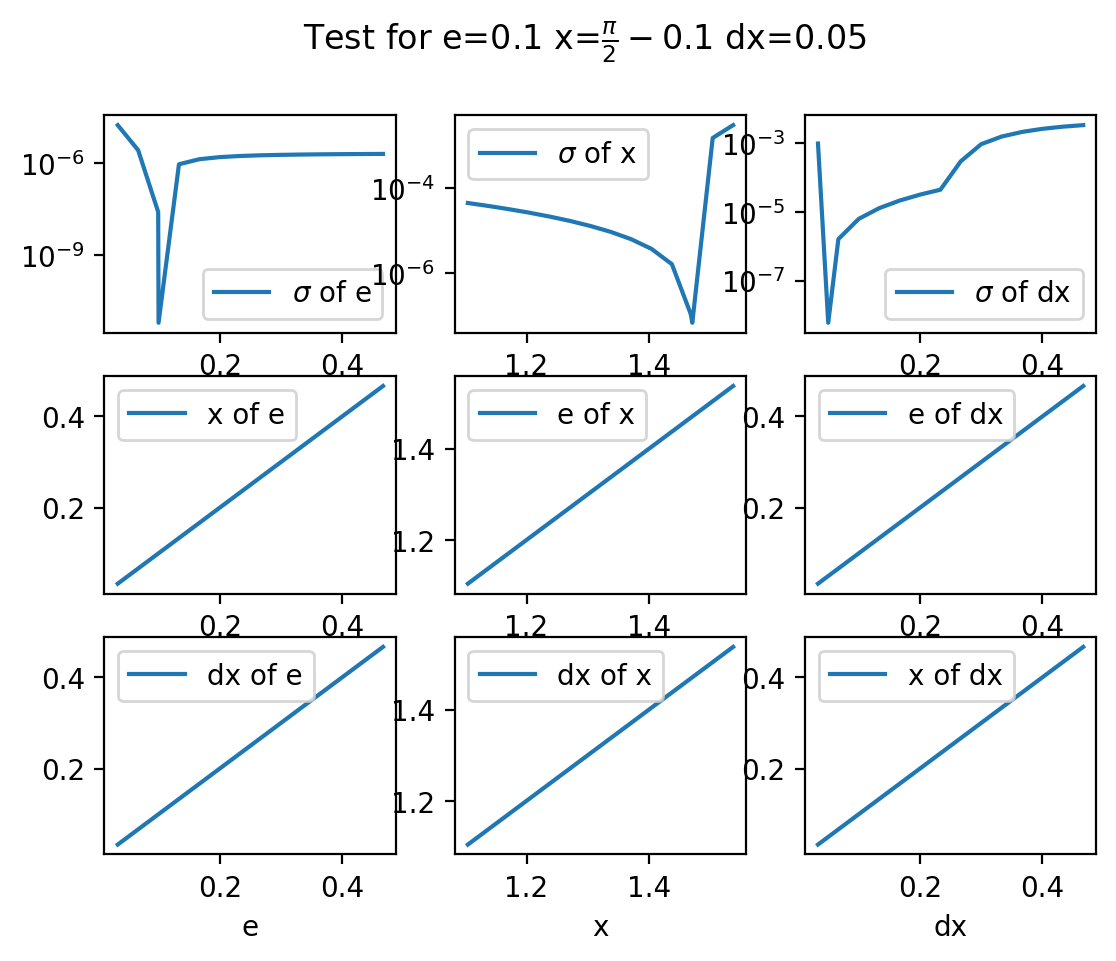

In [13]:
fig, ax = plt.subplots(3, 3)
for i in range(3):
    resj = res
    boundi = method.bounds()[:, i]
    if 0 == i:
        boundi[1] = check_e
    lowi = np.linspace(boundi[0], boundi[1], num=16)
    costi = np.zeros((len(lowi) - 1,))
    res_xi = np.zeros((len(lowi) - 1, 3))
    for j in range(len(lowi) - 1):
        xj = res.x.copy()  # TODO ???
        boundj = method.bounds().copy()
        for k in range(3):
            assert boundj[0, k] < xj[k] and xj[k] < boundj[1, k], f"{k, boundj[0, k], xj[k], boundj[1, k]=}"
        boundj[0, i] = lowi[j]
        boundj[1, i] = lowi[j + 1]
        xj[i] = np.average(boundj[:, i])
        for k in range(3):
            assert boundj[0, k] < xj[k] and xj[k] < boundj[1, k], f"{k, boundj[0, k], xj[k], boundj[1, k]=}"
        resj = solsq(method, xj, boundj)
        costi[j] = resj.cost
        res_xi[j] = resj.x
    ax[0][i].plot(res_xi[:,i], np.sqrt(costi/3.),
                  label=f"$\\sigma$ of {method.id[i]}")
    ax[0][i].set_yscale('log')
    ax[0][i].legend()
    for j in range(3):
        if j != i:
            axji = ax[j + 1 if j < i else j][i]
            axji.plot(res_xi[:,i], res_xi[:,i],
                          label=f"{method.id[j]} of {method.id[i]}")
            axji.legend()
            # axji.set_ylabel(f"{method.id[j]}")
    axji.set_xlabel(f"{method.id[i]}")

pi2="\\frac{\\pi}{2}"
fig.suptitle(f"Test for e={test_e} x=${pi2} {test_x1}$ dx={test_dx}")

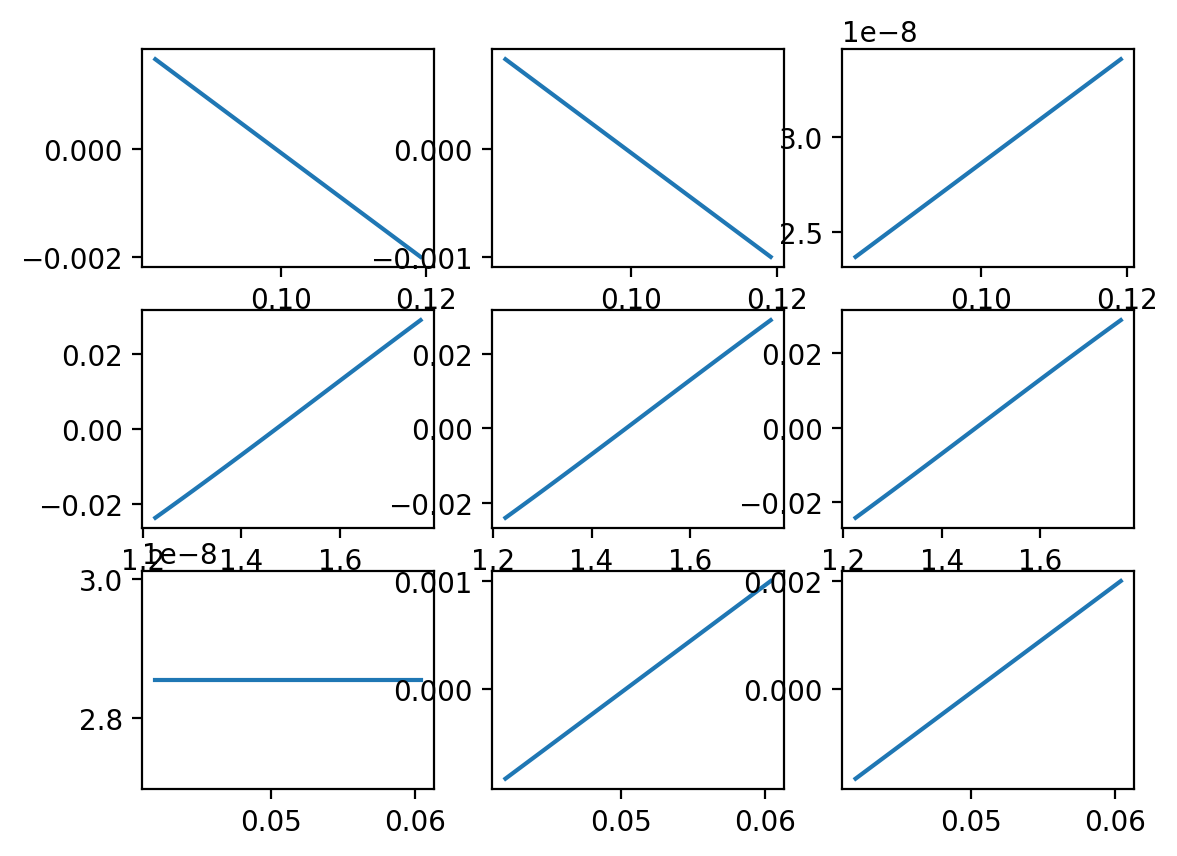

In [14]:
fig, ax = plt.subplots(3, 3)

for i in range(3):
  x = list(res.x)
  x[i] = np.linspace(res.x[i]/1.2, res.x[i]*1.2)
  f = method.fun(x)
  for j in range(3):
    ax[i][j].plot(x[i], f[j])

In [15]:
with np.printoptions(precision=6, suppress=True):
    print(method.__class__.__name__)
    print(method.w, end='\t')
    method.print(res.x)
    for i in range(3):
      x1 = res.x
      method.w[i] = 1000.
      res1 = solsq(method, x1, method.bounds())
      print(method.w, end='\t')
      method.print(res1.x)
      method.w[i] = 1.

cos_jac_method
[1. 1. 1.]	[ 0.099326 -0.10068   0.05034 ]
[1000.    1.    1.]	[ 0.099452 -0.100553  0.050277]
[   1. 1000.    1.]	[ 0.099711 -0.100291  0.050145]
[   1.    1. 1000.]	[ 0.099933 -0.100067  0.050034]
